   Unnamed: 0                                                        Título  Nota  N_Avaliações  Desconto         Marca Material     Gênero        Temporada                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       Review1                                                                                                                                                                                                                                                                                                                                                             R

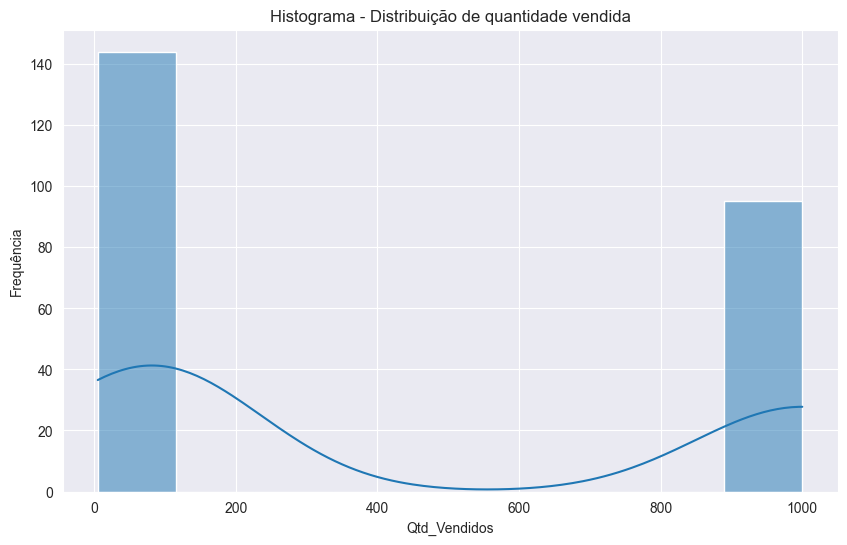

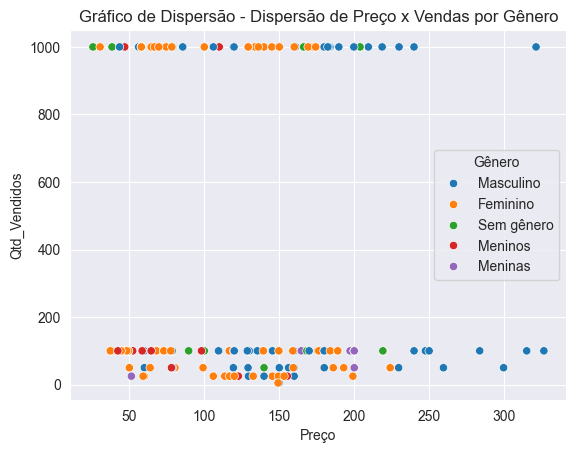

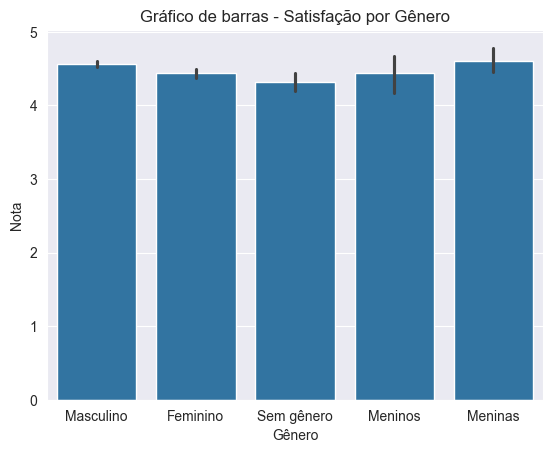

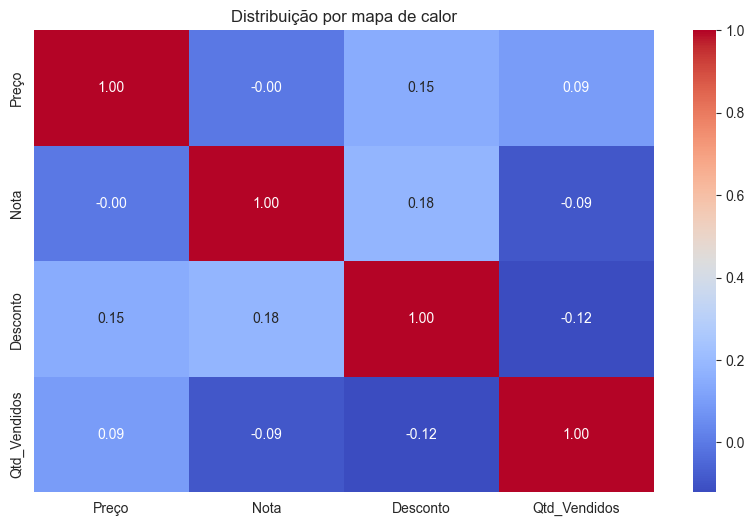

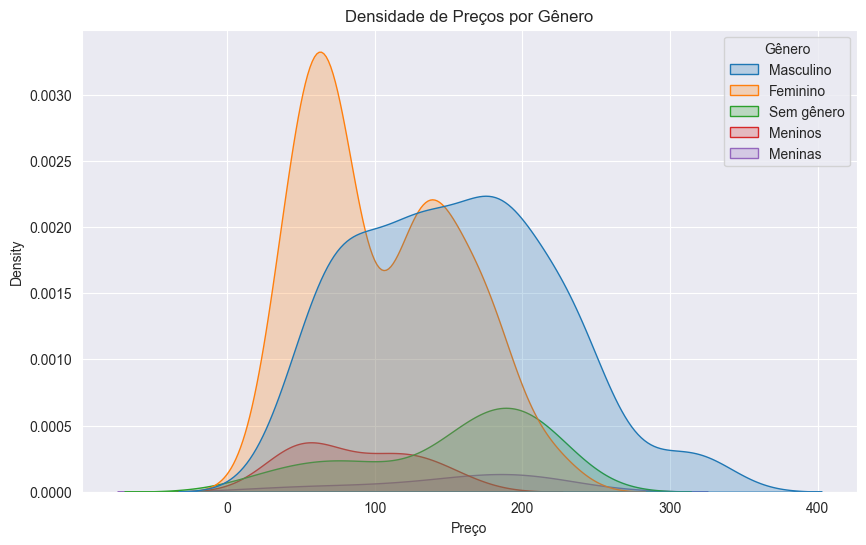

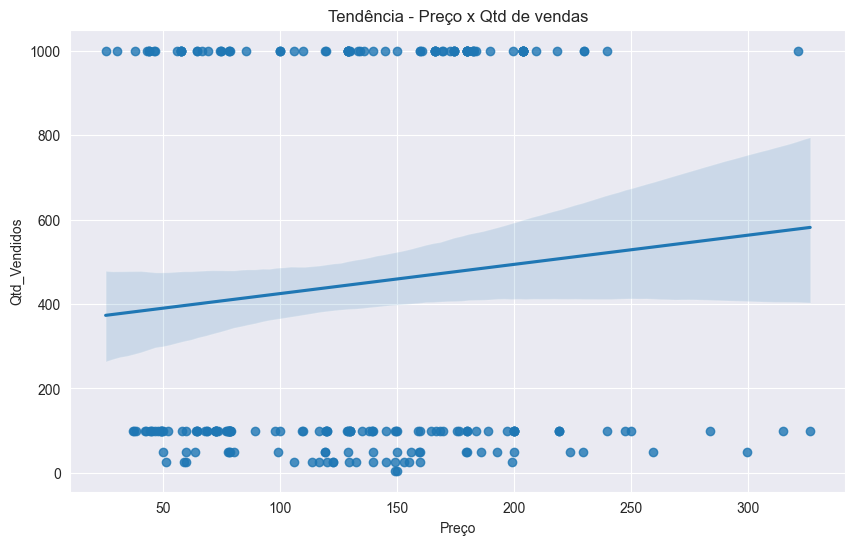

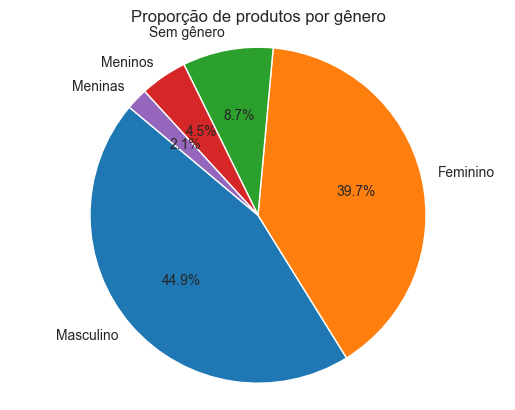

In [3]:
# %%
# # Projeto de Análise de Dados E-commerce

# %%
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# %% [markdown]
# ### Preparando e limpando os dados e Executando o CSV

# %%
df_nao_filtrado = pd.read_csv('ecommerce_estatistica.csv')
pd.to_numeric(df_nao_filtrado['Qtd_Vendidos'], errors='coerce')
generos_validos = df_nao_filtrado['Gênero'].value_counts().nlargest(5).index
df = df_nao_filtrado[df_nao_filtrado['Gênero'].isin(generos_validos)].copy()
print(df.head().to_string())

# %% [markdown]
# ### Histograma - Parâmetros

# %%
plt.figure(figsize=(10,6))
df['Qtd_Vendidos'] = pd.to_numeric(df['Qtd_Vendidos'], errors='coerce')
sns.histplot(data=df, x='Qtd_Vendidos', kde=True)
plt.title('Histograma - Distribuição de quantidade vendida')
plt.xlabel('Qtd_Vendidos')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

# %% [markdown]
# ### Gráfico de dispersão sem ruído

# %%
generos_dispersao = df['Gênero'].value_counts().nlargest(5).index
sns.scatterplot(x='Preço', y='Qtd_Vendidos', data=df, hue='Gênero')
plt.title('Gráfico de Dispersão - Dispersão de Preço x Vendas por Gênero')
plt.show()

# %% [markdown]
# ### Gráfico de barras

# %%
generos_barras = df['Gênero'].value_counts().nlargest(5).index
sns.barplot(data=df, x='Gênero', y='Nota', order=generos_barras)
plt.title('Gráfico de barras - Satisfação por Gênero')
plt.xticks(rotation=0)
plt.show()

# %% [markdown]
# ### Mapa de calor

# %%
plt.figure(figsize=(10,6))
df_corr = df[['Preço', 'Nota', 'Desconto', 'Qtd_Vendidos']].corr()
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Distribuição por mapa de calor")
plt.show()

# %% [markdown]
# ### Gráfico de Densidade

# %%
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Preço', hue='Gênero', fill=True)
plt.title('Densidade de Preços por Gênero')
plt.show()

# %% [markdown]
# ### Gráfico de Regressão

# %%
plt.figure(figsize=(10,6))
sns.regplot(x='Preço', y='Qtd_Vendidos', data=df)
plt.title('Tendência - Preço x Qtd de vendas')
plt.show()

# %% [markdown]
# ### Gráfico de Pizza

# %%
generos = df['Gênero'].value_counts()
plt.pie(generos, labels=generos.index, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Proporção de produtos por gênero')
plt.show()